# Quantum-Inspired Optimization for Construction Crew Scheduling

This notebook asks a practical question: **can an energy-based optimizer produce a shorter construction schedule than a fast classical rule when crews are limited?** It builds the schedule as a QUBO, solves it with classical simulated annealing, and compares it with a CPM-priority list scheduler. A final micro-scale experiment runs QAOA on a local simulator.

> **Terminology note.** CPM alone ignores crew limits and is therefore a lower bound, not necessarily a feasible schedule. D-Wave simulated annealing is a thermal classical heuristic operating on a QUBO/Ising energy landscape; it does not reproduce quantum tunnelling. QAOA is a quantum algorithm, but here it is simulated classically.

In [1]:
import importlib.metadata as metadata
import json
import platform
from dataclasses import asdict
from pathlib import Path

import dimod
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from crew_schedule import (
    analyze_sample,
    build_qubo,
    construction_project,
    decode_sample,
    micro_projects,
    run_benchmarks,
    solve_annealing,
    solve_cpm_list,
    solve_qaoa,
    toy_project,
    tune_annealing,
    validate_schedule,
)
from crew_schedule.experiments import consistency_summary
from crew_schedule.visualization import (
    plot_consistency,
    plot_dependency_graph,
    plot_gantt_comparison,
    plot_qaoa_scaling,
    plot_qubo_matrix,
    plot_scaling,
    plot_tuning,
    save_figure,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES = ROOT / "figures"
RESULTS = ROOT / "results"
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 30)
versions = {
    name: metadata.version(name)
    for name in (
        "dimod",
        "dwave-samplers",
        "networkx",
        "numpy",
        "matplotlib",
        "pandas",
        "qiskit",
        "qiskit-optimization",
    )
}
run_metadata = {
    "python": platform.python_version(),
    "packages": versions,
    "benchmark_seed": 20260719,
    "qaoa_qubit_cap": 18,
}
(RESULTS / "run_metadata.json").write_text(json.dumps(run_metadata, indent=2) + "\n")
display(pd.Series(versions, name="version"))
print(f"Project root: {ROOT}")

dimod                  0.12.22
dwave-samplers           1.8.0
networkx                 3.6.1
numpy                    2.5.1
matplotlib              3.11.1
pandas                   2.3.3
qiskit                   2.5.0
qiskit-optimization      0.7.0
Name: version, dtype: object

Project root: /Users/samarth.gaggar/Downloads/QU-Project


## Foundations: why this problem is interesting

A precedence-only project is easy to propagate through a directed acyclic graph. The difficulty appears when several ready tasks compete for a limited renewable resource. Choosing one task now can delay a different downstream chain, and the number of orderings grows combinatorially. This simplified, non-preemptive model is a single-mode **Resource-Constrained Project Scheduling Problem (RCPSP)**; general RCPSP is NP-hard.

**CPM and the baseline.** Critical Path Method computes earliest/latest times while ignoring crew contention, so its longest path is a lower bound rather than a complete crew-feasible method. We strengthen it with the work bound $\lceil\sum_i d_i/R\rceil$. The classical comparator uses a deterministic schedule-generation rule: whenever crews are free, start ready work in descending remaining-critical-path order.

**QUBO and Ising view.** A QUBO minimizes $E(x)=x^TQx$ for $x_i\in\{0,1\}$. Substitution $x=(1-s)/2$ maps the model to Ising spins $s\in\{-1,+1\}$ with local fields and pairwise couplings. Valid short schedules are designed to occupy the lowest-energy region.

**Annealing.** Classical simulated annealing accepts some uphill moves at high temperature, allowing it to leave local minima, then cools toward low-energy states. It uses the same BQM/Ising representation as quantum annealing but does **not** simulate tunnelling. Current Ocean releases expose the optimized implementation as `dwave.samplers.SimulatedAnnealingSampler`; `neal` is the legacy namespace.

## 1. The construction project

The main example has ten non-preemptive tasks and three interchangeable crews. Each task consumes one crew for its full integer duration. An arrow means the predecessor must finish before the successor starts.

,id,task,duration
0,site_prep,Site preparation,2
1,foundation,Foundation,3
2,framing,Framing,4
3,roofing,Roofing,3
4,plumbing,Plumbing rough-in,2
5,electrical,Electrical rough-in,2
6,insulation,Insulation,2
7,drywall,Drywall,3
8,interior,Interior finish,2
9,inspection,Final inspection,1


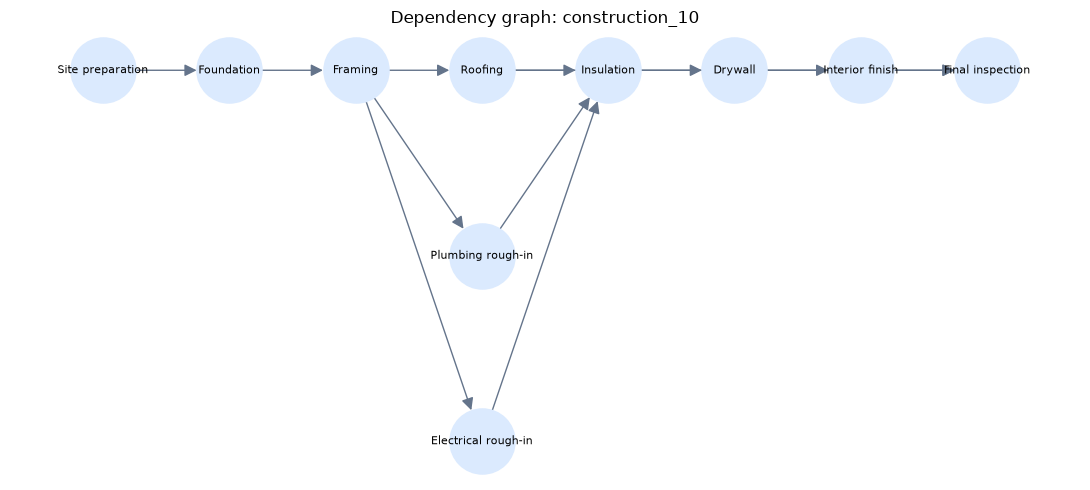

In [2]:
project = construction_project()
task_table = pd.DataFrame(
    [{"id": t.id, "task": t.name, "duration": t.duration} for t in project.tasks]
)
display(task_table)
fig, _ = plot_dependency_graph(project)
save_figure(fig, FIGURES / "construction_dependencies.png")
plt.show()

## 2. From schedule to QUBO

For task $i$ and allowed start slot $t$, let $x_{i,t}=1$ mean that the task starts then. We add a zero-duration finish milestone $F$ after all terminal tasks and minimize

$$\min \sum_t t x_{F,t}.$$

Three penalty families turn the constrained problem into one unconstrained quadratic energy:

1. **Start once:** $A(\sum_t x_{i,t}-1)^2$.
2. **Respect precedence:** add $A x_{i,t}x_{j,s}$ whenever $s<t+d_i$.
3. **Respect crews:** at each slot, use binary slack to penalize active tasks above the crew limit.

We choose $A=H+1$. Since the finish objective ranges only from 0 to $H$, one unit of violation costs more than any possible objective improvement. Earliest/latest precedence bounds remove impossible start variables before the BQM is built.

### Hand-worked four-task encoding

Let `P` be site preparation, `F` foundation, `U` utility rough-in, and `I` inspection. Every duration is one, there is one crew, and the edges are `P→F`, `P→U`, `F→I`, and `U→I`. With horizon $H=4$, $A=5$ and the pruned domains are

$$T_P=\{0,1\},\quad T_F=T_U=\{1,2\},\quad T_I=\{2,3\},\quad T_{Finish}=\{3,4\}.$$

For example, site preparation contributes $5(x_{P,0}+x_{P,1}-1)^2$. The forbidden same-slot choices after a late preparation contribute $5x_{P,1}x_{F,1}+5x_{P,1}x_{U,1}$. Crew capacity in slot one contributes

$$5(x_{P,1}+x_{F,1}+x_{U,1}+z_1-1)^2,$$

where $z_1$ is a binary slack bit. The finish objective is $3x_{Finish,3}+4x_{Finish,4}$. After combining terms, the BQM has 10 start variables, 2 slack variables, and 18 interactions. Exact enumeration should return energy and makespan four.

,real tasks,binary variables,interactions,ground energy,decoded makespan,valid
0,4,12,18,4.0,4,True


start domains            {'prep': (0, 1), 'foundation': (1, 2), 'utilit...
decision feasible                                                     True
crew overload                                                           {}
precedence violations                                                   []
dtype: object

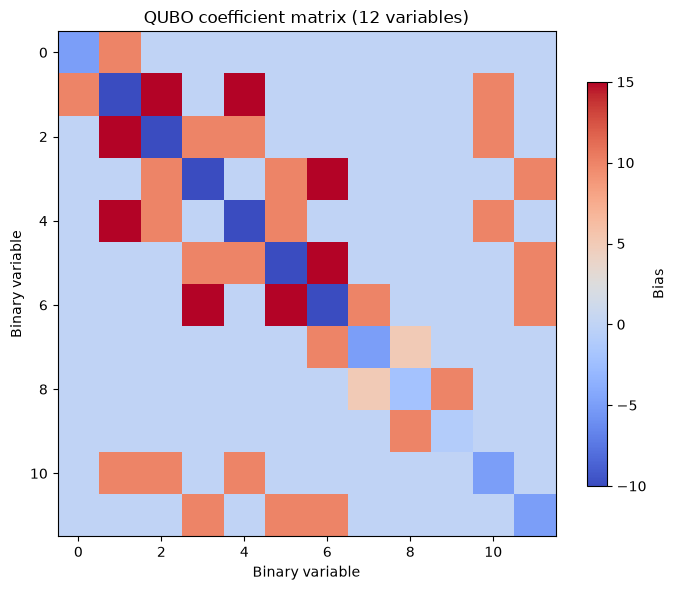

In [3]:
toy = toy_project()
toy_bqm, toy_encoding = build_qubo(toy)
toy_exact = dimod.ExactSolver().sample(toy_bqm)
toy_schedule, toy_errors = decode_sample(toy_exact.first.sample, toy_encoding)
toy_report = analyze_sample(toy_exact.first.sample, toy_encoding)
toy_summary = pd.DataFrame(
    [
        {
            "real tasks": len(toy.tasks),
            "binary variables": toy_bqm.num_variables,
            "interactions": toy_bqm.num_interactions,
            "ground energy": toy_exact.first.energy,
            "decoded makespan": toy_schedule.makespan,
            "valid": not toy_errors,
        }
    ]
)
display(toy_summary)
display(
    pd.Series(
        {
            "start domains": dict(toy_encoding.domains),
            "decision feasible": toy_report["decision_feasible"],
            "crew overload": toy_report["crew_overload"],
            "precedence violations": toy_report["precedence_violations"],
        }
    )
)
assert toy_schedule.makespan == 4 and validate_schedule(toy, toy_schedule)[0]
fig, _ = plot_qubo_matrix(toy_bqm)
save_figure(fig, FIGURES / "toy_qubo_matrix.png")
plt.show()

## 3. Classical baseline and annealing tuning

The classical algorithm gives ready tasks priority according to their remaining critical-path length. Unlike raw CPM, the resulting list schedule never starts more work than the available crews can support. Annealing is stochastic, so four parameter settings are compared across three fixed seeds.

Selected configuration: AnnealingConfig(name='linear_wide', num_reads=200, num_sweeps=2000, beta_schedule_type='linear', beta_range=(0.00016702341700239646, 1.1804414253164597))


,feasible_run_rate,median_makespan,median_runtime
config,,,
quick,1.0,23.0,0.0396
more_reads,1.0,23.0,0.1519
more_sweeps,1.0,23.0,0.1494
linear_wide,1.0,21.0,0.1330


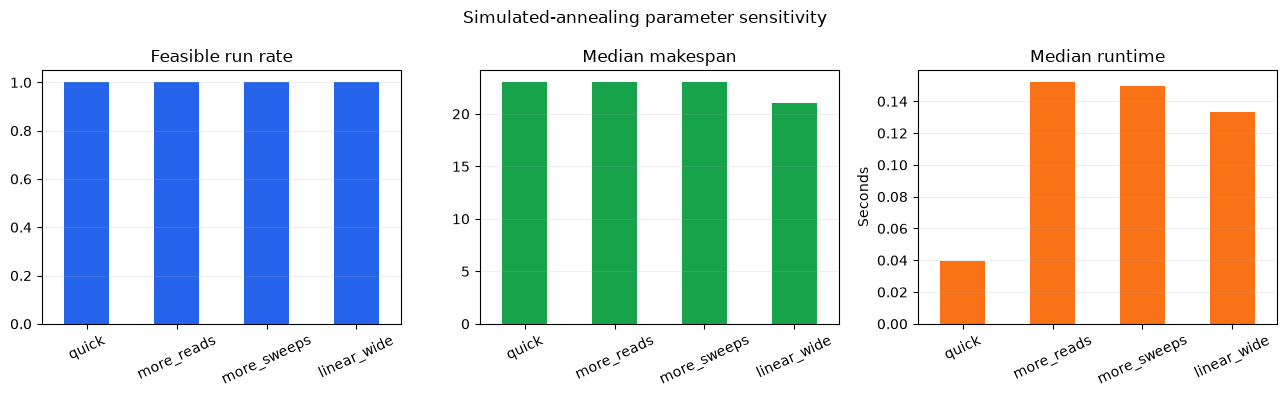

In [4]:
classical = solve_cpm_list(project)
best_config, tuning = tune_annealing(project)
tuning.to_csv(RESULTS / "annealing_tuning.csv", index=False)
print("Selected configuration:", best_config)
display(
    tuning.groupby("config", sort=False)
    .agg(
        feasible_run_rate=("feasible", "mean"),
        median_makespan=("makespan", "median"),
        median_runtime=("runtime", "median"),
    )
    .round(4)
)
fig, _ = plot_tuning(tuning)
save_figure(fig, FIGURES / "annealing_tuning.png")
plt.show()

,method,makespan,runtime_s,feasible,lower_bound
0,CPM-priority list scheduling,20,0.00020,True,20
1,Simulated annealing,20,0.13339,True,20


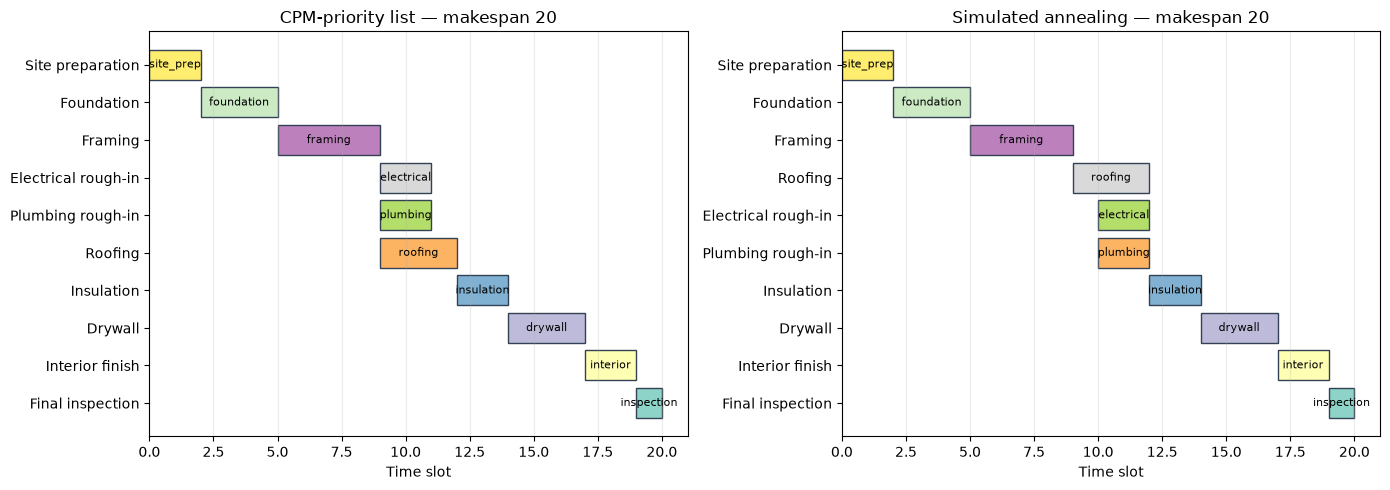

In [5]:
best_params = asdict(best_config)
best_params.pop("name")
main_runs = [solve_annealing(project, seed=seed, **best_params) for seed in (707, 808, 909)]
feasible_main = [run for run in main_runs if run.feasible]
assert feasible_main, "No feasible annealing schedule was found for the main example."
annealed = min(feasible_main, key=lambda run: (run.schedule.makespan, run.energy))
comparison = pd.DataFrame(
    [
        {
            "method": classical.method,
            "makespan": classical.schedule.makespan,
            "runtime_s": classical.runtime,
            "feasible": classical.feasible,
            "lower_bound": classical.metadata["combined_lower_bound"],
        },
        {
            "method": annealed.method,
            "makespan": annealed.schedule.makespan,
            "runtime_s": annealed.runtime,
            "feasible": annealed.feasible,
            "lower_bound": classical.metadata["combined_lower_bound"],
        },
    ]
)
display(comparison.round(5))
comparison.to_csv(RESULTS / "main_comparison.csv", index=False)
assert classical.feasible and annealed.feasible
fig, _ = plot_gantt_comparison(
    project, {"CPM-priority list": classical.schedule, "Simulated annealing": annealed.schedule}
)
save_figure(fig, FIGURES / "construction_gantt_comparison.png")
plt.show()

## 4. Scaling across randomized projects

The reproducible benchmark covers 4, 6, 8, 10, and 12 tasks; two and three crews; two generated DAGs in each cell; and three independent annealing seeds. Medians and interquartile ranges are more informative than a single lucky stochastic run.

Each task after the first receives at least one earlier predecessor; extra forward edges are added with probability 0.15, and durations are uniform integers from 1 through 4. Every seed is stored in the output table. We record makespan, gap to the combined lower bound, improvement over the classical schedule, end-to-end/build/sample time, feasible-read rate, and BQM variables/interactions. A reported annealing schedule is accepted only after independent one-hot, precedence, capacity, and makespan validation.

In [6]:
benchmark = run_benchmarks(annealing_params=best_params)
benchmark.to_csv(RESULTS / "random_benchmarks.csv", index=False)
consistency = consistency_summary(benchmark)
consistency.to_csv(RESULTS / "consistency_summary.csv", index=False)
display(
    benchmark.groupby(["task_count", "crew_limit"])
    .agg(
        classical_makespan=("classical_makespan", "median"),
        annealing_makespan=("annealing_makespan", "median"),
        feasible_run_rate=("annealing_feasible", "mean"),
        median_gap=("gap_to_lower_bound", "median"),
        annealing_runtime_s=("annealing_runtime", "median"),
    )
    .round(4)
)
assert benchmark.loc[benchmark["annealing_feasible"], "annealing_makespan"].notna().all()
outcomes = pd.Series(
    {
        "feasible runs": int(benchmark["annealing_feasible"].sum()),
        "annealing shorter": int((benchmark["improvement_vs_classical"] > 0).sum()),
        "same makespan": int((benchmark["improvement_vs_classical"] == 0).sum()),
        "annealing longer": int((benchmark["improvement_vs_classical"] < 0).sum()),
        "median lower-bound gap": benchmark["gap_to_lower_bound"].median(),
    }
)
display(outcomes)

classical_makespan  annealing_makespan  \
task_count crew_limit                                           
4          2                          9.5                10.0   
           3                          7.0                 7.0   
6          2                          7.5                 8.0   
           3                          9.0                 9.5   
8          2                         12.0                15.0   
           3                         12.5                14.5   
10         2                         19.0                25.0   
           3                         18.5                22.0   
12         2                         14.0                20.0   
           3                         14.5                22.5   

                       feasible_run_rate  median_gap  annealing_runtime_s  
task_count crew_limit                                                      
4          2                         1.0      0.0000               0.0963  
           3                         1.0      0.0000               0.0778  
6          2                         1.0      0.1339               0.1326  
           3                         1.0      0.0500               0.1279  
8          2                         1.0      0.3357               0.2095  
           3                         1.0      0.1818               0.1793  
10         2                         1.0      0.3000               0.2607  
           3                         1.0      0.2128               0.1951  
12         2                         1.0      0.5455               0.3544  
           3                         1.0      0.6202               0.3228

feasible runs             60.000000
annealing shorter          0.000000
same makespan             16.000000
annealing longer          44.000000
median lower-bound gap     0.170673
dtype: float64

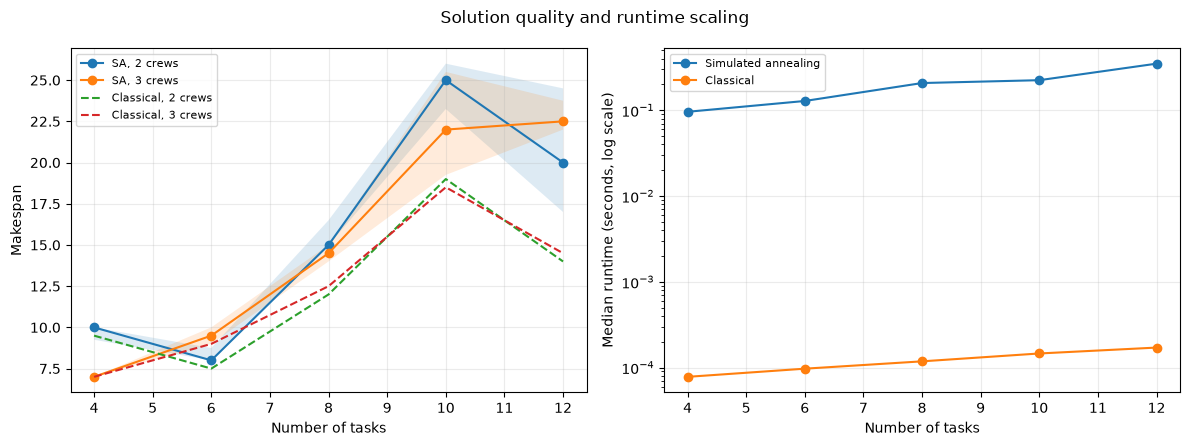

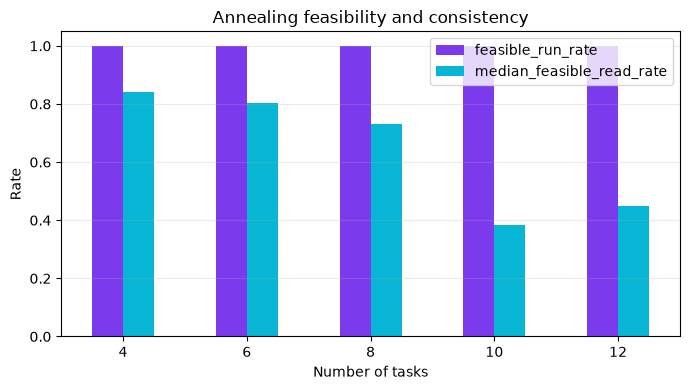

In [7]:
fig, _ = plot_scaling(benchmark)
save_figure(fig, FIGURES / "scaling_quality_runtime.png")
plt.show()
fig, _ = plot_consistency(benchmark)
save_figure(fig, FIGURES / "annealing_consistency.png")
plt.show()

## 5. QAOA: a quantum algorithm on a classical simulator

Every BQM variable becomes a qubit. State-vector memory therefore grows exponentially, while the time-indexed model's variable count grows with both tasks and horizon. QAOA is run only for the 2–4 task micro-projects, using depths $p=1,2$, three seeds, 1,024 shots, COBYLA with at most 100 evaluations, and an 18-qubit cap. The ten-task model is explicitly reported as not run. Exact NumPy eigensolver energies verify each micro BQM.

feasible_run_rate  median_makespan  \
task_count reps status                                                    
2          1    completed                          1.0              2.0   
           2    completed                          1.0              2.0   
3          1    completed                          1.0              3.0   
           2    completed                          1.0              3.0   
4          1    completed                          1.0              4.0   
           2    completed                          1.0              4.0   
10         1    not run—qubit limit                0.0              NaN   

                                     median_runtime_s  qubits  
task_count reps status                                         
2          1    completed                      0.2621       8  
           2    completed                      0.3205       8  
3          1    completed                      0.4616      10  
           2    completed                      0.5977      10  
4          1    completed                      0.9896      12  
           2    completed                      1.4041      12  
10         1    not run—qubit limit            0.0012      93

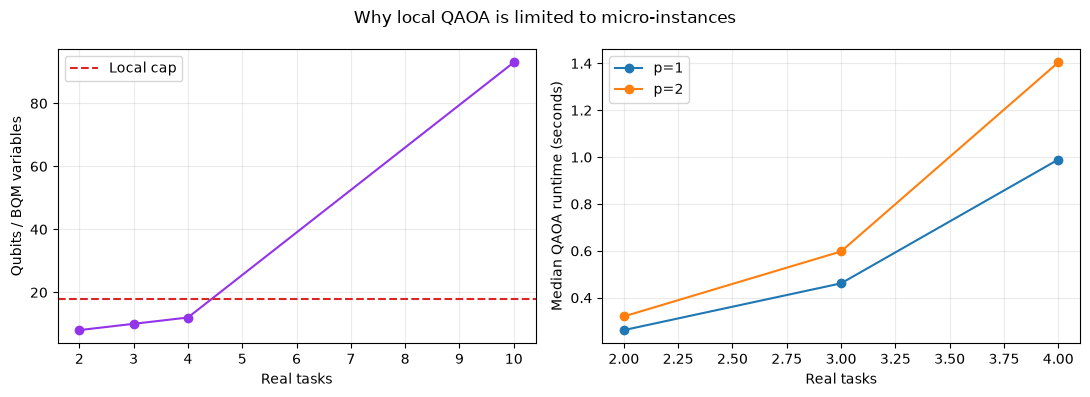

In [8]:
qaoa_rows = []
for micro in micro_projects():
    for reps in (1, 2):
        for seed in (11, 22, 33):
            result = solve_qaoa(micro, reps=reps, seed=seed, shots=1024, maxiter=100)
            qaoa_rows.append(
                {
                    "instance": micro.name,
                    "task_count": len(micro.tasks),
                    "reps": reps,
                    "seed": seed,
                    "status": result.metadata["status"],
                    "feasible": result.feasible,
                    "makespan": result.schedule.makespan if result.schedule else np.nan,
                    "energy": result.energy,
                    "exact_energy": result.metadata.get("exact_ground_energy"),
                    "qubits": result.metadata["qubits"],
                    "runtime": result.runtime,
                    "feasible_probability": result.metadata.get("feasible_probability"),
                }
            )
large_qaoa = solve_qaoa(project, reps=1, seed=11)
qaoa_rows.append(
    {
        "instance": project.name,
        "task_count": len(project.tasks),
        "reps": 1,
        "seed": 11,
        "status": large_qaoa.metadata["status"],
        "feasible": False,
        "makespan": np.nan,
        "energy": np.nan,
        "exact_energy": np.nan,
        "qubits": large_qaoa.metadata["qubits"],
        "runtime": large_qaoa.runtime,
        "feasible_probability": np.nan,
    }
)
qaoa_results = pd.DataFrame(qaoa_rows)
qaoa_results.to_csv(RESULTS / "qaoa_micro_results.csv", index=False)
display(
    qaoa_results.groupby(["task_count", "reps", "status"], dropna=False)
    .agg(
        feasible_run_rate=("feasible", "mean"),
        median_makespan=("makespan", "median"),
        median_runtime_s=("runtime", "median"),
        qubits=("qubits", "max"),
    )
    .round(4)
)
assert set(qaoa_results[qaoa_results["task_count"] <= 4]["status"]) == {"completed"}
fig, _ = plot_qaoa_scaling(qaoa_results)
save_figure(fig, FIGURES / "qaoa_scaling.png")
plt.show()

## References and reproducibility

- [D-Wave Ocean documentation](https://docs.dwavequantum.com/en/latest/ocean/) and [dimod BQM reference](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/)
- [D-Wave simulated annealing API](https://docs.dwavequantum.com/en/latest/ocean/api_ref_samplers/generated/dwave.samplers.SimulatedAnnealingSampler.sample.html)
- [NetworkX DAG algorithms](https://networkx.org/documentation/stable/reference/algorithms/dag.html)
- [Qiskit Optimization QUBO/QAOA tutorial](https://qiskit-community.github.io/qiskit-optimization/tutorials/03_minimum_eigen_optimizer.html)
- [D-Wave job-shop scheduling example](https://github.com/dwave-examples/job-shop-scheduling)

Package versions are displayed at the top and written to `results/run_metadata.json`. Mathematical details, experimental policy, limitations, and exact commands are also documented in the repository's `docs/` and `README.md`.

## 6. Conclusions and limits

- The CPM/resource lower bound tells us what no feasible schedule can beat; the CPM-priority list algorithm supplies a very fast feasible baseline.
- Simulated annealing matches the baseline on the fixed project, but in the seeded random matrix it ties 16 schedules and is longer in 44; none are shorter. Quality still varies with seed and settings, so one lucky run is not evidence of superiority.
- QAOA uses the same QUBO but is practical here only for micro-instances. All runs decode a feasible real-task schedule, although some measured slack assignments remain above the exact ground energy. The simulator experiment is not evidence of quantum speedup.
- Results apply to the simplified assumptions: interchangeable crews, one crew per task, integer durations, no preemption, and no calendars or skill types. A production RCPSP would require richer resources and a stronger exact benchmark.

In [9]:
summary = {
    "main_lower_bound": int(classical.metadata["combined_lower_bound"]),
    "classical_makespan": int(classical.schedule.makespan),
    "annealing_makespan": int(annealed.schedule.makespan),
    "benchmark_feasible_run_rate": float(benchmark["annealing_feasible"].mean()),
    "qaoa_micro_feasible_run_rate": float(
        qaoa_results[qaoa_results["task_count"] <= 4]["feasible"].mean()
    ),
}
pd.Series(summary, name="value").to_csv(RESULTS / "executive_summary.csv")
display(pd.Series(summary, name="value"))
figure_count = len(list(FIGURES.glob("*.png")))
table_count = len(list(RESULTS.glob("*.csv")))
print(f"Wrote {figure_count} figures and {table_count} result tables.")

main_lower_bound                20.0
classical_makespan              20.0
annealing_makespan              20.0
benchmark_feasible_run_rate      1.0
qaoa_micro_feasible_run_rate     1.0
Name: value, dtype: float64

Wrote 7 figures and 6 result tables.
